# PINN 2D — Control DVFS Fisicamente Realista (v3)

## Que corrige esta version

La version anterior tenia cuatro problemas estructurales:

| Problema | Sintoma | Causa raiz | Correccion v3 |
|---|---|---|---|
| Control omnipresente | Throttling activo incluso con chip frio | Sin condicion de activacion termica | Gate sigmoidal sobre u |
| Throttling ilimitado | c=1 elimina hotspot completamente | c en [0,1] sin techo fisico | C_MAX=0.35 (max 35% reduccion) |
| Costo insuficiente | Red prefiere throttling total | lambda_energy demasiado bajo | Triple penalizacion: cuadratica + lineal + suavidad |
| Normalizacion temporal rota | ControlNet identica para t=0.1 y t=4.9 | Normalizacion por 1 en vez de T_FINAL | Normalizar siempre t/T_FINAL |

## La PDE corregida

```
u_t = alpha * Laplacian(u) + Q(x,y) * (1 - gate(u) * c(x,y,t))
```

donde:
- `gate(u) = sigmoid(BETA * (u - u_safe))`: apagado si frio, activo si caliente
- `c_max = 0.35`: el DVFS nunca reduce la fuente mas del 35%
- `c(x,y,t) = sum_i a_i(t) * phi_i(x,y)`: localizado en actuadores fisicos

## Por que C_MAX = 0.35

En CPUs modernas (Intel, AMD, ARM) el throttling maximo de frecuencia
reduce la potencia dinamica aprox un 25-40%. Existe siempre una potencia
de fuga irreducible. C_MAX=0.35 modela este limite fisico real.

## Por que ReLU^2 en vez de softplus para los hotspots

softplus(u - u_safe) es positivo para TODO u, incluso fresco.
Esto incentiva al controlador a mantener el chip innecesariamente frio.
ReLU^2 = max(0, u-u_safe)^2 es exactamente cero para u <= u_safe,
eliminando el incentivo al throttling preventivo.


## 0. Imports y configuracion

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle, Patch
from matplotlib.lines import Line2D

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
else:
    print("  CPU — entrenar ~11k epocas puede tomar 20-40 min")


Dispositivo: cpu
  CPU — entrenar ~11k epocas puede tomar 20-40 min


## 1. Parametros fisicos y de entrenamiento

### Por que T_FINAL = 5.0

Con t en [0,1] el chip apenas alcanza regimen transitorio.
La difusividad alpha=0.005 da tiempo caracteristico tau = L^2/alpha = 200.
Con T_FINAL=5 vemos acumulacion termica real, respuesta del DVFS y
difusion lateral entre cores vecinos.

**Normalizacion critica**: ControlNet recibe t/T_FINAL como entrada.
Sin esto, Tanh satura para t > 1.5, dando predicciones identicas en todo el horizonte.

### Parametros de control

- C_MAX = 0.35: max 35% reduccion en generacion de calor (potencia de fuga irreducible)
- BETA_GATE = 15: transicion del gate en rango +/-0.2 alrededor de u_safe

### Balance de perdidas

Version anterior: lambda_hotspot/lambda_energy = 8/0.5 = 16 (demasiado agresivo)
Version nueva:    lambda_hotspot/lambda_energy = 5/3   = 1.7 (equilibrado)

Ademas se agregan:
- lambda_usage: penaliza throttling sostenido aunque sea pequeno (uso acumulado)
- lambda_smooth: penaliza cambios bruscos de frecuencia (inercia del hardware)


In [66]:
# ===========================================================================
# PARAMETROS FISICOS
# ===========================================================================


alpha = 0.008

u_init = 0.20
u_safe = 0.80
u_crit = 0.86

HEAT_STRENGTHS = [7.5, 8.5, 7.5, 9.5]

HEAT_SIGMA = 0.06

T_FINAL=5.0

# ===========================================================================
# ACTUADORES DVFS
# ===========================================================================

ACTUATOR_CENTERS = [(0.25, 0.25), (0.75, 0.75), (0.60, 0.20), (0.30, 0.70)]
HEAT_CENTERS = [
    (0.25, 0.25),
    (0.75, 0.75),
    (0.60, 0.20),
    (0.30, 0.70)
]
SIGMA_C          = 0.12
N_ACTUATORS      = len(ACTUATOR_CENTERS)

# Limite fisico de throttling (35% max reduccion termica)
C_MAX = 0.35

# Pendiente del gate termico: mayor = transicion mas abrupta
BETA_GATE = 15.0

# ===========================================================================
# PESOS DE PERDIDA
# ===========================================================================
# Antes: lambda_hot/lambda_E = 16 -> throttling total
# Ahora: lambda_hot/lambda_E = 1.7 -> equilibrado

lambda_pde     = 1.0
lambda_ic      = 10.0
lambda_bc      = 5.0
lambda_hotspot = 20.0    # ReLU^2: solo penaliza violaciones reales
lambda_usage   = 0.4    # Penalizacion lineal: costo de uso sostenido
lambda_smooth  = 0.8    # Suavidad temporal: inercia del hardware DVFS
lambda_sparse  = 0.5

# ===========================================================================
# ENTRENAMIENTO Y ARQUITECTURA
# ===========================================================================

WARMUP_EPOCHS = 3000
CTRL_EPOCHS   = 8000
TOTAL_EPOCHS  = WARMUP_EPOCHS + CTRL_EPOCHS

N_F = 4000; N_I = 600; N_B = 400

HIDDEN_U = 64; LAYERS_U = 5
HIDDEN_C = 32; LAYERS_C = 4

LR_WARMUP = 1e-3; LR_CTRL = 5e-4; LR_MIN = 1e-5; GRAD_CLIP = 1.0
N_VIS = 64; T_FRAMES = 48

print("=" * 60)
print("CONFIGURACION FISICA v3 (Realista)")
print("=" * 60)
print(f"  alpha={alpha}  u_safe={u_safe}  T_FINAL={T_FINAL}")
print(f"  C_MAX={C_MAX} (throttling max {C_MAX*100:.0f}%)")
print(f"  BETA_GATE={BETA_GATE}")
print(f"  lambda_usage={lambda_usage}  lambda_smooth={lambda_smooth} [NUEVO]")


CONFIGURACION FISICA v3 (Realista)
  alpha=0.008  u_safe=0.8  T_FINAL=5.0
  C_MAX=0.35 (throttling max 35%)
  BETA_GATE=15.0
  lambda_usage=0.4  lambda_smooth=0.8 [NUEVO]


## 2. Layout del chip

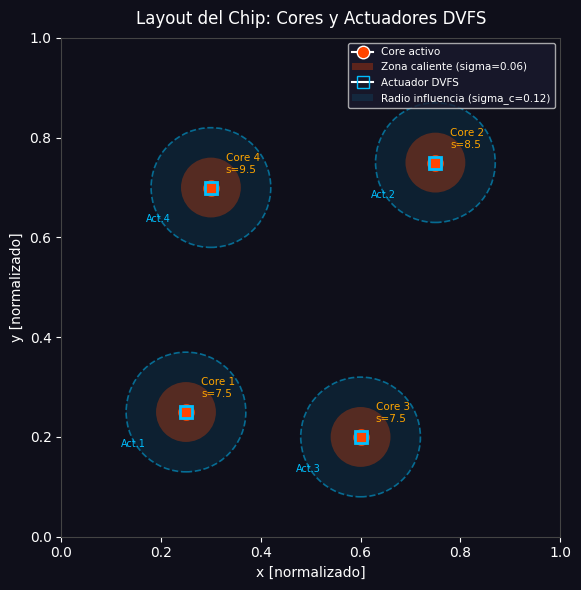

Layout: 4 cores, 4 actuadores DVFS


In [67]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_facecolor('#0f0f1a'); fig.patch.set_facecolor('#0f0f1a')
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
ax.set_title("Layout del Chip: Cores y Actuadores DVFS", color='white', fontsize=12, pad=10)
ax.set_xlabel("x [normalizado]", color='white')
ax.set_ylabel("y [normalizado]", color='white')
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_edgecolor('#444')

for cx,cy in ACTUATOR_CENTERS:
    ax.add_patch(Circle((cx,cy), SIGMA_C, color='deepskyblue', fill=True, alpha=0.10, lw=0))
    ax.add_patch(Circle((cx,cy), SIGMA_C, color='deepskyblue', fill=False, alpha=0.5, lw=1.2, ls='--'))
for cx,cy in HEAT_CENTERS:
    ax.add_patch(Circle((cx,cy), HEAT_SIGMA, color='orangered', fill=True, alpha=0.30, lw=0))
for i,((cx,cy),s) in enumerate(zip(HEAT_CENTERS, HEAT_STRENGTHS)):
    ax.plot(cx,cy,'o',color='orangered',markersize=11,zorder=5)
    ax.text(cx+0.03,cy+0.03,f'Core {i+1}\ns={s}',color='orange',fontsize=7.5,zorder=6)
for i,(cx,cy) in enumerate(ACTUATOR_CENTERS):
    ax.plot(cx,cy,'s',color='deepskyblue',markersize=9,
            markerfacecolor='none',markeredgewidth=2,zorder=7)
    ax.text(cx-0.13,cy-0.07,f'Act.{i+1}',color='deepskyblue',fontsize=7,zorder=8)

legend_elements = [
    Line2D([0],[0],marker='o',color='w',markerfacecolor='orangered',markersize=9,label='Core activo'),
    Patch(facecolor='orangered',alpha=0.30,label=f'Zona caliente (sigma={HEAT_SIGMA})'),
    Line2D([0],[0],marker='s',color='w',markerfacecolor='none',
           markeredgecolor='deepskyblue',markersize=9,label='Actuador DVFS'),
    Patch(facecolor='deepskyblue',alpha=0.10,label=f'Radio influencia (sigma_c={SIGMA_C})'),
]
ax.legend(handles=legend_elements,loc='upper right',fontsize=7.5,
          facecolor='#1a1a2e',labelcolor='white',framealpha=0.8)
plt.tight_layout()
plt.savefig("chip_layout.png", dpi=130, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(f"Layout: {len(HEAT_CENTERS)} cores, {N_ACTUATORS} actuadores DVFS")


## 3. Arquitectura de las redes neuronales

### Correccion critica: normalizacion temporal

Version anterior normalizaba t como `2*t - 1`.
Para t in [0, T_FINAL=5] esto da valores en [-1, 9].
La Tanh satura para |x| > 2, produciendo gradientes nulos para t > 1.5.
ControlNet aprende a ser constante en la mayor parte del horizonte.

**Fix**: normalizar como `2*(t/T_FINAL) - 1` in [-1, 1] siempre.

### ControlNet: salida = sigmoid en (0,1)

La salida a_i(t) in (0,1) se multiplica por C_MAX en control_field().
Esto mantiene la red en rango bien condicionado y el limite fisico
se impone de forma transparente fuera de la red.


In [68]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden, n_layers, out_dim, out_gain=0.1):
        super().__init__()
        layers = []
        prev = in_dim
        for _ in range(n_layers):
            lin = nn.Linear(prev, hidden)
            nn.init.xavier_normal_(lin.weight)
            nn.init.zeros_(lin.bias)
            layers += [lin, nn.Tanh()]
            prev = hidden
        out_lin = nn.Linear(prev, out_dim)
        nn.init.xavier_normal_(out_lin.weight, gain=out_gain)
        nn.init.zeros_(out_lin.bias)
        layers.append(out_lin)
        self.net = nn.Sequential(*layers)


class TemperatureNet(MLP):
    """
    Aprende u(x, y, t): campo de temperatura del chip.
    Entrada: x,y in [0,1] -> [-1,1]; t normalizado por T_FINAL -> [-1,1]
    Salida: u en R (anclada por perdida PDE + IC)
    """
    def __init__(self):
        super().__init__(in_dim=3, hidden=HIDDEN_U,
                         n_layers=LAYERS_U, out_dim=1, out_gain=0.1)

    def forward(self, x, y, t):
        xn = 2.0 * x - 1.0
        yn = 2.0 * y - 1.0
        tn = 2.0 * (t / T_FINAL) - 1.0   # CORRECCION: dividir por T_FINAL
        return self.net(torch.cat([xn, yn, tn], dim=-1))


class ControlNet(MLP):
    """
    Aprende a(t) = [a1(t),...,aM(t)] in (0,1)^M: intensidades de actuadores.

    Entrada: solo t (normalizado por T_FINAL).
    Salida: sigmoid(z) in (0,1)^M.

    El escalado por C_MAX ocurre en control_field(), no aqui.
    Esto mantiene la red en rango bien condicionado.

    Fisica: ControlNet solo accede al tiempo, no al campo completo de
    temperatura. Esto modela que el controlador DVFS real solo tiene
    acceso a informacion temporal (scheduling), no a medicion punto a punto.
    """
    def __init__(self):
        super().__init__(in_dim=1, hidden=HIDDEN_C,
                         n_layers=LAYERS_C, out_dim=N_ACTUATORS, out_gain=0.1)

    def forward(self, t):
        tn = 2.0 * (t / T_FINAL) - 1.0   # CORRECCION: dividir por T_FINAL
        return torch.sigmoid(self.net(tn))  # in (0,1)^M


u_net = TemperatureNet().to(device)
c_net = ControlNet().to(device)

n_u = sum(p.numel() for p in u_net.parameters())
n_c = sum(p.numel() for p in c_net.parameters())
print(f"TemperatureNet : {n_u:,} parametros")
print(f"ControlNet     : {n_c:,} parametros  (entrada=t/T_FINAL, salida in (0,1)^{N_ACTUATORS})")
print(f"Total          : {n_u+n_c:,}")


TemperatureNet : 16,961 parametros
ControlNet     : 3,364 parametros  (entrada=t/T_FINAL, salida in (0,1)^4)
Total          : 20,325


## 4. Fisica corregida: gate termico + limite de throttling

### Las tres capas del control efectivo

```
c_eff(x,y,t) = gate(u) * C_MAX * sum_i a_i(t) * phi_i(x,y)
```

Capa 1 - Gate termico: gate(u) = sigmoid(BETA*(u - u_safe))
  - u << u_safe: gate ~ 0 -> control apagado (chip frio, sin throttling)
  - u >> u_safe: gate ~ 1 -> control maximo permitido
  - Diferenciable: gradientes fluyen correctamente hacia ambas redes

Capa 2 - Limite fisico: C_MAX = 0.35
  - c_eff <= C_MAX < 1 siempre
  - Q_eff = Q*(1-c_eff) >= Q*(1-C_MAX) = Q*0.65 siempre
  - El chip SIEMPRE genera al menos 65% de su calor nominal

Capa 3 - Localizacion espacial: gaussianas phi_i centradas en actuadores
  - Cada actuador afecta solo su zona (radio SIGMA_C)
  - a_i(t) decide cuanto throttlea el core i en el instante t

### Por que softplus causaba sobrecontrol

softplus(u - u_safe) = log(1 + exp(u - u_safe)) > 0 para TODO u.
Penaliza incluso temperaturas seguras -> incentiva throttling preventivo.

ReLU^2(u - u_safe) = max(0, u-u_safe)^2 es exactamente 0 para u <= u_safe.
Solo penaliza violaciones reales del umbral termico.


In [69]:
def heat_source(x, y):
    """
    Q(x,y) = suma de gaussianas representando cores activos.
    Q >= 0 siempre.
    """
    Q = torch.zeros_like(x)
    for (cx,cy),s in zip(HEAT_CENTERS, HEAT_STRENGTHS):
        Q = Q + s * torch.exp(-((x-cx)**2 + (y-cy)**2) / (2.0*HEAT_SIGMA**2))
    return Q


def actuator_basis(x, y):
    """
    Funciones base gaussianas de los M actuadores.
    phi_i(x,y) = exp(-||r - r_i||^2 / sigma_c^2)
    Retorna tensor [N, M].
    """
    Phi = []
    for ax_, ay_ in ACTUATOR_CENTERS:
        Phi.append(torch.exp(-((x-ax_)**2 + (y-ay_)**2) / SIGMA_C**2))
    return torch.cat(Phi, dim=-1)


def thermal_gate(u):
    """
    gate(u) = sigmoid(BETA_GATE * (u - u_safe))
    Apagado si frio, activo si caliente. Diferenciable en todas partes.
    """
    return torch.sigmoid(BETA_GATE * (u - u_safe))


def control_field(x, y, t):
    """
    Campo de throttling c(x,y,t) in [0, C_MAX].
    c = clamp(C_MAX * sum_i a_i(t)*phi_i(x,y), 0, C_MAX)
    El gate termico se aplica fuera (en effective_source) para
    mantener el acoplamiento u_net <-> c_net en el grafo.
    """
    a   = c_net(t)             # [N, M] in (0,1)
    Phi = actuator_basis(x, y) # [N, M] in [0,1]
    c_raw = (Phi * a).sum(dim=-1, keepdim=True)  # [N,1]
    return torch.clamp(C_MAX * c_raw, 0.0, C_MAX)


def effective_source(x, y, t, u):
    """
    Fuente termica efectiva tras DVFS.
    Q_eff = Q * (1 - gate(u)*c(x,y,t))

    u DEBE ser u_net(x,y,t) del mismo grafo computacional.
    El gate conecta u_net y c_net -> gradientes fluyen hacia ambas redes.

    Garantia: Q_eff >= Q*(1-C_MAX) = Q*0.65 siempre.
    """
    Q    = heat_source(x, y)
    c    = control_field(x, y, t)
    gate = thermal_gate(u)
    c_eff = gate * c           # in [0, C_MAX]
    return Q * (1.0 - c_eff), Q, c, c_eff


# Verificacion
x_t = torch.rand(8,1); y_t = torch.rand(8,1)
t_t = T_FINAL * torch.rand(8,1)
u_t = u_net(x_t, y_t, t_t)
Q_eff_t, Q_t, c_t, ce_t = effective_source(x_t, y_t, t_t, u_t.detach())

print("Verificacion de la fisica corregida:")
print(f"  Q       : [{Q_t.min():.3f}, {Q_t.max():.3f}]")
print(f"  c       : [{c_t.min():.4f}, {c_t.max():.4f}]  (debe <= C_MAX={C_MAX})")
print(f"  c_eff   : [{ce_t.min():.4f}, {ce_t.max():.4f}]")
print(f"  Q_eff   : [{Q_eff_t.min():.3f}, {Q_eff_t.max():.3f}]")
frac = (Q_eff_t/(Q_t+1e-8)).mean().item()
print(f"  Q_eff/Q media: {frac:.3f}  (debe ser >= {1-C_MAX:.2f})")
g_cold = torch.sigmoid(torch.tensor(BETA_GATE*(0.40-u_safe))).item()
g_hot  = torch.sigmoid(torch.tensor(BETA_GATE*(0.90-u_safe))).item()
print(f"  gate(u=0.40) = {g_cold:.5f}  (chip frio -> control OFF)")
print(f"  gate(u=0.90) = {g_hot:.5f}  (chip caliente -> control ON)")


Verificacion de la fisica corregida:
  Q       : [0.000, 1.213]
  c       : [0.0002, 0.0716]  (debe <= C_MAX=0.35)
  c_eff   : [0.0000, 0.0000]
  Q_eff   : [0.000, 1.213]
  Q_eff/Q media: 1.000  (debe ser >= 0.65)
  gate(u=0.40) = 0.00247  (chip frio -> control OFF)
  gate(u=0.90) = 0.81757  (chip caliente -> control ON)


## 5. Visualizacion del gate termico y la fuente de calor

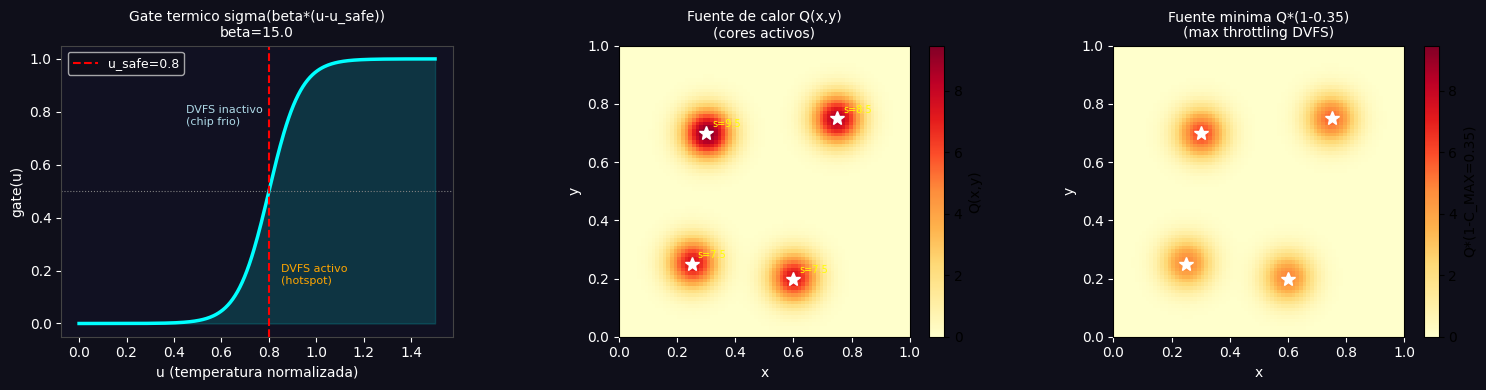

Con C_MAX=0.35, la fuente minima es 65% de Q
-> Los hotspots se reducen pero NO desaparecen completamente


In [70]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor('#0f0f1a')

# Gate termico
ax = axes[0]; ax.set_facecolor('#111122')
u_rng = np.linspace(0.0, 1.5, 300)
gate_vals = 1/(1+np.exp(-BETA_GATE*(u_rng - u_safe)))
ax.plot(u_rng, gate_vals, 'cyan', lw=2.5)
ax.axvline(u_safe, color='red', lw=1.5, ls='--', label=f'u_safe={u_safe}')
ax.axhline(0.5, color='gray', lw=0.8, ls=':')
ax.fill_between(u_rng, 0, gate_vals, alpha=0.15, color='cyan')
ax.set_xlabel("u (temperatura normalizada)", color='white')
ax.set_ylabel("gate(u)", color='white')
ax.set_title(f"Gate termico sigma(beta*(u-u_safe))\nbeta={BETA_GATE}", color='white', fontsize=10)
ax.tick_params(colors='white'); ax.legend(fontsize=9,facecolor='#0f0f1a',labelcolor='white')
ax.set_ylim(-0.05, 1.05)
for sp in ax.spines.values(): sp.set_edgecolor('#444')
ax.text(u_safe-0.35, 0.75, 'DVFS inactivo\n(chip frio)', color='lightblue', fontsize=8)
ax.text(u_safe+0.05, 0.15, 'DVFS activo\n(hotspot)', color='orange', fontsize=8)

# Fuente Q(x,y)
ax = axes[1]; ax.set_facecolor('#0f0f1a')
n_q = 80
xs_q = torch.linspace(0,1,n_q); ys_q = torch.linspace(0,1,n_q)
Xq,Yq = torch.meshgrid(xs_q,ys_q,indexing='ij')
xfq=Xq.reshape(-1,1); yfq=Yq.reshape(-1,1)
with torch.no_grad():
    Q_vis = heat_source(xfq,yfq).reshape(n_q,n_q).numpy()
im = ax.imshow(Q_vis.T, origin='lower', extent=[0,1,0,1], cmap='YlOrRd', aspect='equal')
plt.colorbar(im, ax=ax, label='Q(x,y)', fraction=0.046)
ax.set_title("Fuente de calor Q(x,y)\n(cores activos)", color='white', fontsize=10)
ax.set_xlabel("x",color='white'); ax.set_ylabel("y",color='white')
ax.tick_params(colors='white')
for (cx,cy),s in zip(HEAT_CENTERS,HEAT_STRENGTHS):
    ax.plot(cx,cy,'w*',markersize=10)
    ax.text(cx+0.02,cy+0.02,f's={s}',color='yellow',fontsize=7)

# Reduccion maxima posible
ax = axes[2]; ax.set_facecolor('#111122')
Q_min = Q_vis * (1.0 - C_MAX)
im2 = ax.imshow(Q_min.T, origin='lower', extent=[0,1,0,1],
                cmap='YlOrRd', aspect='equal', vmin=0, vmax=Q_vis.max())
plt.colorbar(im2, ax=ax, label=f'Q*(1-C_MAX={C_MAX})', fraction=0.046)
ax.set_title(f"Fuente minima Q*(1-{C_MAX})\n(max throttling DVFS)", color='white', fontsize=10)
ax.set_xlabel("x",color='white'); ax.set_ylabel("y",color='white')
ax.tick_params(colors='white')
for cx,cy in HEAT_CENTERS: ax.plot(cx,cy,'w*',markersize=10)

plt.tight_layout()
plt.savefig("gate_and_sources.png", dpi=120, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(f"Con C_MAX={C_MAX}, la fuente minima es {(1-C_MAX)*100:.0f}% de Q")
print("-> Los hotspots se reducen pero NO desaparecen completamente")


## 6. Funcion de perdida corregida

### El funcional de control optimo

L = lambda_pde * L_PDE
  + lambda_ic  * L_IC
  + lambda_bc  * L_BC
  + lambda_hotspot * L_hotspot    [ReLU^2, no softplus]
  + lambda_energy  * E[c_eff^2]  [cuadratico: penaliza control intenso]
  + lambda_usage   * E[c_eff^2]    [cuadratico: penaliza uso intenso]
  + lambda_smooth  * E[(da/dt)^2] [suavidad temporal DVFS]

### Por que penalizacion lineal ademas de cuadratica

La penalizacion cuadratica ||c||^2 penaliza poco valores pequenos.
Un throttling sostenido de c=0.1 durante todo el horizonte tiene
bajo coste cuadratico pero alto coste de rendimiento acumulado.
La penalizacion lineal E[c] penaliza el uso total independientemente
de la magnitud: modela la degradacion de rendimiento acumulada.

### Por que suavidad temporal lambda_smooth * E[(da/dt)^2]

Los P-states de DVFS tienen latencias de cambio de 1-10 us.
Cambios bruscos generan transientes de corriente que danan reguladores.
La penalizacion de suavidad modela esta inercia del hardware.


In [71]:
def compute_loss_dvfs(with_control=True, return_parts=False):
    """
    PINN-DVFS Loss v4
    =================

    Cambios importantes respecto a versiones anteriores:
    ----------------------------------------------------
    1. Hotspot basado en temperatura crítica u_crit
       -> permite temperaturas moderadamente altas
       -> evita throttling preventivo constante

    2. Eliminada penalización redundante loss_energy
       -> antes se castigaba DOS veces magnitud espacial

    3. Penalización aplicada DIRECTAMENTE sobre actuadores a_i(t)
       -> físicamente más realista para DVFS

    4. Smoothness reducido
       -> evita favorecer controles constantes

    5. Penalización cuadrática sobre actuadores
       -> equilibrio razonable entre:
            - evitar saturación
            - permitir control moderado

    6. Sparsity L1 adicional
       -> incentiva que pocos actuadores se activen
    """

    # =====================================================================
    # 1. PUNTOS DE COLLOCACION PDE
    # =====================================================================

    x_f = torch.rand(N_F, 1, device=device, requires_grad=True)
    y_f = torch.rand(N_F, 1, device=device, requires_grad=True)
    t_f = T_FINAL * torch.rand(N_F, 1, device=device, requires_grad=True)

    # Temperatura PINN
    u_f = u_net(x_f, y_f, t_f)

    # Derivadas automaticas
    u_t = torch.autograd.grad(
        u_f, t_f,
        torch.ones_like(u_f),
        create_graph=True
    )[0]

    u_x = torch.autograd.grad(
        u_f, x_f,
        torch.ones_like(u_f),
        create_graph=True
    )[0]

    u_y = torch.autograd.grad(
        u_f, y_f,
        torch.ones_like(u_f),
        create_graph=True
    )[0]

    u_xx = torch.autograd.grad(
        u_x, x_f,
        torch.ones_like(u_x),
        create_graph=True
    )[0]

    u_yy = torch.autograd.grad(
        u_y, y_f,
        torch.ones_like(u_y),
        create_graph=True
    )[0]

    # =====================================================================
    # 2. FUENTE EFECTIVA CON DVFS
    # =====================================================================

    if with_control:

        # Q_eff = Q * (1-c)
        Q_eff, Q_raw, c_f, c_eff_f = effective_source(
            x_f, y_f, t_f, u_f
        )

    else:

        Q_eff = heat_source(x_f, y_f)

        c_eff_f = torch.zeros(
            N_F, 1, device=device
        )

    # =====================================================================
    # 3. RESIDUO PDE
    # =====================================================================

    residual = (
        u_t
        - alpha * (u_xx + u_yy)
        - Q_eff
    )

    loss_pde = torch.mean(residual**2)

    # =====================================================================
    # 4. CONDICION INICIAL
    # =====================================================================

    x_i = torch.rand(N_I, 1, device=device)
    y_i = torch.rand(N_I, 1, device=device)

    t_i = torch.zeros(N_I, 1, device=device)

    u_i = u_net(x_i, y_i, t_i)

    loss_ic = torch.mean(
        (u_i - u_init)**2
    )

    # =====================================================================
    # 5. FRONTERAS NEUMANN
    # du/dn = 0
    # =====================================================================

    t_b = T_FINAL * torch.rand(N_B, 1, device=device)
    s_b = torch.rand(N_B, 1, device=device)

    # x = 0
    x_bl = torch.zeros(
        N_B, 1,
        device=device,
        requires_grad=True
    )

    du_bl = torch.autograd.grad(
        u_net(x_bl, s_b, t_b),
        x_bl,
        torch.ones(N_B,1,device=device),
        create_graph=True
    )[0]

    # x = 1
    x_br = torch.ones(
        N_B, 1,
        device=device,
        requires_grad=True
    )

    du_br = torch.autograd.grad(
        u_net(x_br, s_b, t_b),
        x_br,
        torch.ones(N_B,1,device=device),
        create_graph=True
    )[0]

    # y = 0
    y_bb = torch.zeros(
        N_B, 1,
        device=device,
        requires_grad=True
    )

    du_bb = torch.autograd.grad(
        u_net(s_b, y_bb, t_b),
        y_bb,
        torch.ones(N_B,1,device=device),
        create_graph=True
    )[0]

    # y = 1
    y_bt = torch.ones(
        N_B, 1,
        device=device,
        requires_grad=True
    )

    du_bt = torch.autograd.grad(
        u_net(s_b, y_bt, t_b),
        y_bt,
        torch.ones(N_B,1,device=device),
        create_graph=True
    )[0]

    loss_bc = (
        torch.mean(du_bl**2)
        + torch.mean(du_br**2)
        + torch.mean(du_bb**2)
        + torch.mean(du_bt**2)
    )

    # =====================================================================
    # 6. HOTSPOT LOSS (MUY IMPORTANTE)
    # =====================================================================

    """
    Antes:
        penalizacion inmediata en u_safe

    Problema:
        el sistema aprendia:
            "cualquier subida es peligrosa"

    Ahora:
        SOLO penalizamos temperaturas realmente criticas.
    """

    loss_hotspot = torch.mean(
        torch.relu(u_f - u_crit)**2
    )

    # =====================================================================
    # 7. PENALIZACION SOBRE ACTUADORES
    # =====================================================================

    if with_control:

        # tiempos aleatorios
        t_ctrl = T_FINAL * torch.rand(
            512, 1, device=device
        )

        # salida directa de actuadores
        a_vals = c_net(t_ctrl)

        # -------------------------------------------------------------
        # penalizacion cuadratica
        # evita throttling extremo
        # -------------------------------------------------------------

        loss_usage = torch.mean(a_vals**2)

        # -------------------------------------------------------------
        # sparsity L1
        # favorece pocos actuadores activos
        # -------------------------------------------------------------

        loss_sparse = torch.mean(torch.abs(a_vals))

    else:

        loss_usage = torch.tensor(
            0.0, device=device
        )

        loss_sparse = torch.tensor(
            0.0, device=device
        )

    # =====================================================================
    # 8. SUAVIDAD TEMPORAL
    # =====================================================================

    if with_control:

        dt_sm = T_FINAL * 0.01

        t_sm1 = T_FINAL * torch.rand(
            256, 1, device=device
        )

        t_sm2 = t_sm1 + dt_sm

        a1 = c_net(t_sm1)
        a2 = c_net(t_sm2)

        da_dt = (a2 - a1) / dt_sm

        loss_smooth = torch.mean(
            da_dt**2
        )

    else:

        loss_smooth = torch.tensor(
            0.0, device=device
        )

    # =====================================================================
    # 9. LOSS TOTAL
    # =====================================================================

    loss = (
        lambda_pde      * loss_pde
        + lambda_ic     * loss_ic
        + lambda_bc     * loss_bc
        + lambda_hotspot* loss_hotspot
        + lambda_usage  * loss_usage
        + lambda_sparse * loss_sparse
        + lambda_smooth * loss_smooth
    )

    # =====================================================================
    # 10. DEBUG
    # =====================================================================

    if return_parts:

        return loss, {

            "pde": loss_pde.item(),

            "ic": loss_ic.item(),

            "bc": loss_bc.item(),

            "hotspot": loss_hotspot.item(),

            "usage": loss_usage.item(),

            "sparse": loss_sparse.item(),

            "smooth": loss_smooth.item(),

            "total": loss.item(),
        }

    return loss


print("="*60)
print("Funcion de perdida DVFS v4 definida")
print("="*60)

print(f"u_safe = {u_safe}")
print(f"u_crit = {u_crit}")

print()
print("Cambios importantes:")
print("  ✓ hotspot solo sobre temperatura critica")
print("  ✓ penalizacion directa sobre actuadores")
print("  ✓ sparsity L1")
print("  ✓ eliminada penalizacion redundante energy")
print("  ✓ throttling preventivo reducido")

print()
print("Lambdas sugeridos:")
print(f"  lambda_hotspot = {lambda_hotspot}")
print(f"  lambda_usage   = {lambda_usage}")
print(f"  lambda_sparse  = {lambda_sparse}")
print(f"  lambda_smooth  = {lambda_smooth}")

Funcion de perdida DVFS v4 definida
u_safe = 0.8
u_crit = 0.86

Cambios importantes:
  ✓ hotspot solo sobre temperatura critica
  ✓ penalizacion directa sobre actuadores
  ✓ sparsity L1
  ✓ eliminada penalizacion redundante energy
  ✓ throttling preventivo reducido

Lambdas sugeridos:
  lambda_hotspot = 20.0
  lambda_usage   = 0.4
  lambda_sparse  = 0.5
  lambda_smooth  = 0.8


## 7. Entrenamiento en dos fases

### Fase 1 - Warm-up: por que es esencial para el gate termico

Con el gate termico, si u_net predice u ~ 0.2 al inicio:
  gate = sigmoid(15*(0.2 - 0.75)) = sigmoid(-8.25) ~ 0.00026

El gradiente del sigmoid en ese punto es gate*(1-gate) ~ 0.00026.
ControlNet recibe gradientes practicamente nulos y no aprende nada.

El warm-up garantiza que u_net prediga hotspots reales (u > u_safe)
antes de activar ControlNet.

### Monitoreo de la Fase 2

En cada checkpoint imprimimos:
- a_mean: intensidades medias. Deben crecer gradualmente, no de golpe.
- c_eff_mean: magnitud del throttling efectivo. Debe ser positivo pero moderado.
- gate_mean: fraccion del dominio con gate activo. Relacionado con el area en hotspot.
- hot%: fraccion del chip con u > u_safe. Debe bajar vs warm-up, pero NO a cero.


In [72]:
opt_warmup = torch.optim.Adam(u_net.parameters(), lr=LR_WARMUP, weight_decay=1e-5)
sched_warmup = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_warmup, T_max=WARMUP_EPOCHS, eta_min=LR_MIN)

opt_full = torch.optim.Adam(
    list(u_net.parameters()) + list(c_net.parameters()),
    lr=LR_CTRL, weight_decay=1e-5)
sched_full = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_full, T_max=CTRL_EPOCHS, eta_min=LR_MIN)

parts_history = []

# =====================================================================
# FASE 1: WARM-UP
# =====================================================================
print("=" * 65)
print(f"FASE 1: WARM-UP ({WARMUP_EPOCHS} epocas) - TemperatureNet, sin DVFS")
print("=" * 65)

for epoch in range(1, WARMUP_EPOCHS + 1):
    u_net.train(); c_net.eval()
    opt_warmup.zero_grad()
    loss, parts = compute_loss_dvfs(with_control=False, return_parts=True)
    loss.backward()
    nn.utils.clip_grad_norm_(u_net.parameters(), GRAD_CLIP)
    opt_warmup.step(); sched_warmup.step()
    parts_history.append(("warmup", parts))

    if epoch % 500 == 0 or epoch == 1:
        with torch.no_grad():
            xm=torch.rand(1500,1,device=device)
            ym=torch.rand(1500,1,device=device)
            tm=T_FINAL*torch.rand(1500,1,device=device)
            um=u_net(xm,ym,tm)
        pct = (um > u_safe).float().mean().item()*100
        print(f"  ep {epoch:5d} | L={parts['total']:.5f}"
              f" | pde={parts['pde']:.5f} | ic={parts['ic']:.5f}"
              f" | u_max={um.max():.3f} | {pct:.1f}% sobre u_safe")

with torch.no_grad():
    xd=torch.rand(3000,1,device=device); yd=torch.rand(3000,1,device=device)
    td=T_FINAL*torch.rand(3000,1,device=device); ud=u_net(xd,yd,td)
pct_hot = (ud > u_safe).float().mean().item()*100
print(f"Post-warmup: u in [{ud.min():.3f}, {ud.max():.3f}]")
print(f"  {pct_hot:.1f}% puntos con u > u_safe")
if pct_hot < 2.0:
    print("  ADVERTENCIA: pocos hotspots. Subir HEAT_STRENGTHS.")
else:
    print("  OK: hotspots visibles. ControlNet puede aprender.")

# =====================================================================
# FASE 2: DVFS ACTIVO
# =====================================================================
print()
print("=" * 65)
print(f"FASE 2: DVFS ({CTRL_EPOCHS} epocas) - TemperatureNet + ControlNet")
print("=" * 65)

for epoch in range(1, CTRL_EPOCHS + 1):
    u_net.train(); c_net.train()
    opt_full.zero_grad()
    loss, parts = compute_loss_dvfs(with_control=True, return_parts=True)
    loss.backward()
    nn.utils.clip_grad_norm_(
        list(u_net.parameters()) + list(c_net.parameters()), GRAD_CLIP)
    opt_full.step(); sched_full.step()
    parts_history.append(("control", parts))

    if epoch % 500 == 0 or epoch == 1:
        with torch.no_grad():
            tm2=T_FINAL*torch.rand(500,1,device=device)
            xm2=torch.rand(500,1,device=device)
            ym2=torch.rand(500,1,device=device)
            um2=u_net(xm2,ym2,tm2)
            am2=c_net(tm2)
            gate_m=thermal_gate(um2)
            cm2=control_field(xm2,ym2,tm2)
            ceff_m=gate_m*cm2
        a_mean=am2.mean(dim=0).cpu().numpy()
        pct_h=(um2>u_safe).float().mean().item()*100
        print(f"  ep {epoch:5d}/{CTRL_EPOCHS}"
              f" | L={parts['total']:.4f}"
              f" | hot={parts['hotspot']:.5f}"
              f" | U={parts['usage']:.5f}"
              f" | S={parts['smooth']:.5f}")
        print(f"    a=[{', '.join(f'{v:.3f}' for v in a_mean)}]"
              f"  c_eff={ceff_m.mean():.4f}"
              f"  gate={gate_m.mean():.4f}"
              f"  hot%={pct_h:.1f}")

print("=" * 65)
print("Entrenamiento completado")
with torch.no_grad():
    tf2=T_FINAL*torch.rand(1000,1,device=device)
    xf2=torch.rand(1000,1,device=device); yf2=torch.rand(1000,1,device=device)
    uf2=u_net(xf2,yf2,tf2); af2=c_net(tf2)
    gate_f2=thermal_gate(uf2); cf2=control_field(xf2,yf2,tf2)
    ceff_f2=gate_f2*cf2
print(f"  c_eff media={ceff_f2.mean():.4f}  max={ceff_f2.max():.4f}  (debe <= C_MAX={C_MAX})")
pct_fn=(uf2>u_safe).float().mean().item()*100
print(f"  {pct_fn:.1f}% puntos por encima de u_safe")


FASE 1: WARM-UP (3000 epocas) - TemperatureNet, sin DVFS
  ep     1 | L=3.41243 | pde=2.94293 | ic=0.04534 | u_max=0.042 | 0.0% sobre u_safe
  ep   500 | L=2.73341 | pde=2.72060 | ic=0.00074 | u_max=0.956 | 15.6% sobre u_safe
  ep  1000 | L=2.86301 | pde=2.85267 | ic=0.00005 | u_max=1.047 | 17.7% sobre u_safe
  ep  1500 | L=2.84570 | pde=2.82893 | ic=0.00018 | u_max=1.060 | 20.5% sobre u_safe
  ep  2000 | L=2.83538 | pde=2.82381 | ic=0.00011 | u_max=1.009 | 18.1% sobre u_safe
  ep  2500 | L=3.02165 | pde=3.01015 | ic=0.00014 | u_max=1.033 | 20.0% sobre u_safe
  ep  3000 | L=2.93155 | pde=2.91759 | ic=0.00014 | u_max=1.021 | 18.3% sobre u_safe
Post-warmup: u in [0.187, 1.023]
  19.2% puntos con u > u_safe
  OK: hotspots visibles. ControlNet puede aprender.

FASE 2: DVFS (8000 epocas) - TemperatureNet + ControlNet
  ep     1/8000 | L=3.0511 | hot=0.00054 | U=0.24993 | S=0.00001
    a=[0.500, 0.500, 0.500, 0.500]  c_eff=0.0090  gate=0.2623  hot%=27.4
  ep   500/8000 | L=2.8457 | hot=0.001

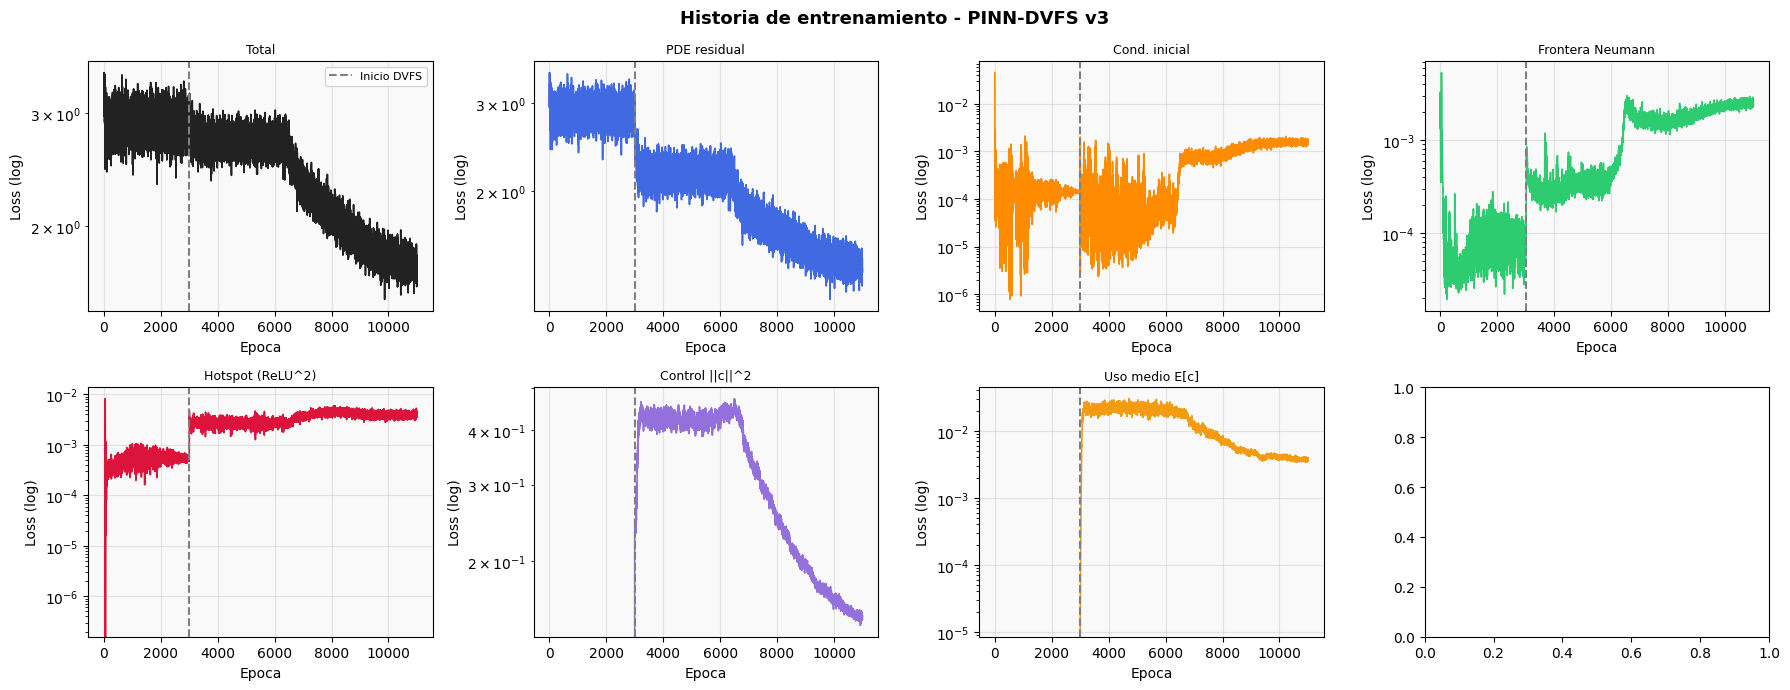

Senales de entrenamiento sano:
  L_hotspot baja pero NO llega a cero (hotspots persisten)
  L_energy, L_usage, L_smooth crecen al activar DVFS
  L_pde se mantiene bajo en ambas fases


In [73]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle("Historia de entrenamiento - PINN-DVFS v3",
             fontsize=13, fontweight='bold')

keys   = ["total","pde","ic","bc","hotspot","usage","smooth"]
titles = ["Total","PDE residual","Cond. inicial","Frontera Neumann",
          "Hotspot (ReLU^2)","Control ||c||^2","Uso medio E[c]","Suavidad da/dt"]
colors = ["#222","royalblue","darkorange","#2ecc71",
          "crimson","mediumpurple","#f39c12","#1abc9c"]

for ax, key, title, color in zip(axes.flat, keys, titles, colors):
    vals = [p[key] for (_,p) in parts_history]
    ax.semilogy(vals, color=color, lw=1.2)
    ax.axvline(WARMUP_EPOCHS, color='gray', ls='--', lw=1.5,
               label='Inicio DVFS' if key=='total' else None)
    if key == 'total': ax.legend(fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Epoca"); ax.set_ylabel("Loss (log)")
    ax.grid(True, alpha=0.3); ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig("loss_history_v3.png", dpi=120, bbox_inches='tight')
plt.show()
print("Senales de entrenamiento sano:")
print("  L_hotspot baja pero NO llega a cero (hotspots persisten)")
print("  L_energy, L_usage, L_smooth crecen al activar DVFS")
print("  L_pde se mantiene bajo en ambas fases")


## 8. Modelo de referencia (sin DVFS) y funciones de evaluacion

In [77]:
u_net_ref = TemperatureNet().to(device)
opt_ref   = torch.optim.Adam(u_net_ref.parameters(), lr=5e-4, weight_decay=1e-5)
sched_ref = torch.optim.lr_scheduler.CosineAnnealingLR(opt_ref, T_max=4000, eta_min=1e-5)

print("Entrenando referencia sin DVFS (4000 epocas)...")
for ep in range(4000):
    u_net_ref.train(); opt_ref.zero_grad()
    xr=torch.rand(N_F,1,device=device,requires_grad=True)
    yr=torch.rand(N_F,1,device=device,requires_grad=True)
    tr=T_FINAL*torch.rand(N_F,1,device=device,requires_grad=True)
    ur=u_net_ref(xr,yr,tr)
    ur_t  = torch.autograd.grad(ur, tr, torch.ones_like(ur), create_graph=True)[0]
    ur_x  = torch.autograd.grad(ur, xr, torch.ones_like(ur), create_graph=True)[0]
    ur_y  = torch.autograd.grad(ur, yr, torch.ones_like(ur), create_graph=True)[0]
    ur_xx = torch.autograd.grad(ur_x,xr,torch.ones_like(ur_x),create_graph=True)[0]
    ur_yy = torch.autograd.grad(ur_y,yr,torch.ones_like(ur_y),create_graph=True)[0]
    Qr    = heat_source(xr, yr)
    lp    = torch.mean((ur_t - alpha*(ur_xx+ur_yy) - Qr)**2)
    xi=torch.rand(N_I,1,device=device); yi=torch.rand(N_I,1,device=device)
    ti=torch.zeros(N_I,1,device=device)
    li = torch.mean((u_net_ref(xi,yi,ti) - u_init)**2)
    loss_r = lambda_pde*lp + lambda_ic*li
    loss_r.backward()
    nn.utils.clip_grad_norm_(u_net_ref.parameters(), GRAD_CLIP)
    opt_ref.step(); sched_ref.step()
    if ep % 1000 == 0:
        print(f"  ep {ep:4d} | pde={lp.item():.5f} | ic={li.item():.5f}")
print("Referencia lista")

@torch.no_grad()
def eval_temperature(t_val, controlled=True, n=N_VIS):
    net = u_net if controlled else u_net_ref; net.eval()
    xs=torch.linspace(0,1,n,device=device); ys=torch.linspace(0,1,n,device=device)
    Xg,Yg=torch.meshgrid(xs,ys,indexing='ij')
    xf=Xg.reshape(-1,1); yf=Yg.reshape(-1,1); tf=torch.full_like(xf, t_val)
    return net(xf,yf,tf).reshape(n,n).cpu().numpy()

@torch.no_grad()
def eval_control_field(t_val, n=N_VIS):
    u_net.eval(); c_net.eval()
    xs=torch.linspace(0,1,n,device=device); ys=torch.linspace(0,1,n,device=device)
    Xg,Yg=torch.meshgrid(xs,ys,indexing='ij')
    xf=Xg.reshape(-1,1); yf=Yg.reshape(-1,1); tf=torch.full_like(xf, t_val)
    u_f=u_net(xf,yf,tf)
    c_f=control_field(xf,yf,tf)
    gate=thermal_gate(u_f)
    c_eff=gate*c_f
    t_sc = torch.tensor(
    [[t_val]],
    device=device,
    dtype=next(c_net.parameters()).dtype
    )
    a_vals=c_net(t_sc).squeeze().cpu().numpy()
    return (c_eff.reshape(n,n).cpu().numpy(),
            c_f.reshape(n,n).cpu().numpy(),
            gate.reshape(n,n).cpu().numpy(),
            a_vals)

@torch.no_grad()
def eval_actuator_timeseries(n_t=100):
    c_net.eval()
    t_range=torch.linspace(0,T_FINAL,n_t,device=device).reshape(-1,1)
    return np.linspace(0,T_FINAL,n_t), c_net(t_range).cpu().numpy()

print("Funciones de evaluacion definidas")


Entrenando referencia sin DVFS (4000 epocas)...
  ep    0 | pde=3.31787 | ic=0.04285
  ep 1000 | pde=0.40821 | ic=0.00365
  ep 2000 | pde=0.10596 | ic=0.00117
  ep 3000 | pde=0.06169 | ic=0.00055
Referencia lista
Funciones de evaluacion definidas


## 9. Comparacion estatica: snapshots a lo largo del horizonte

/var/folders/7_/jx69qx9x14vcjds7rh_4np4w0000gn/T/ipykernel_53501/1554106207.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


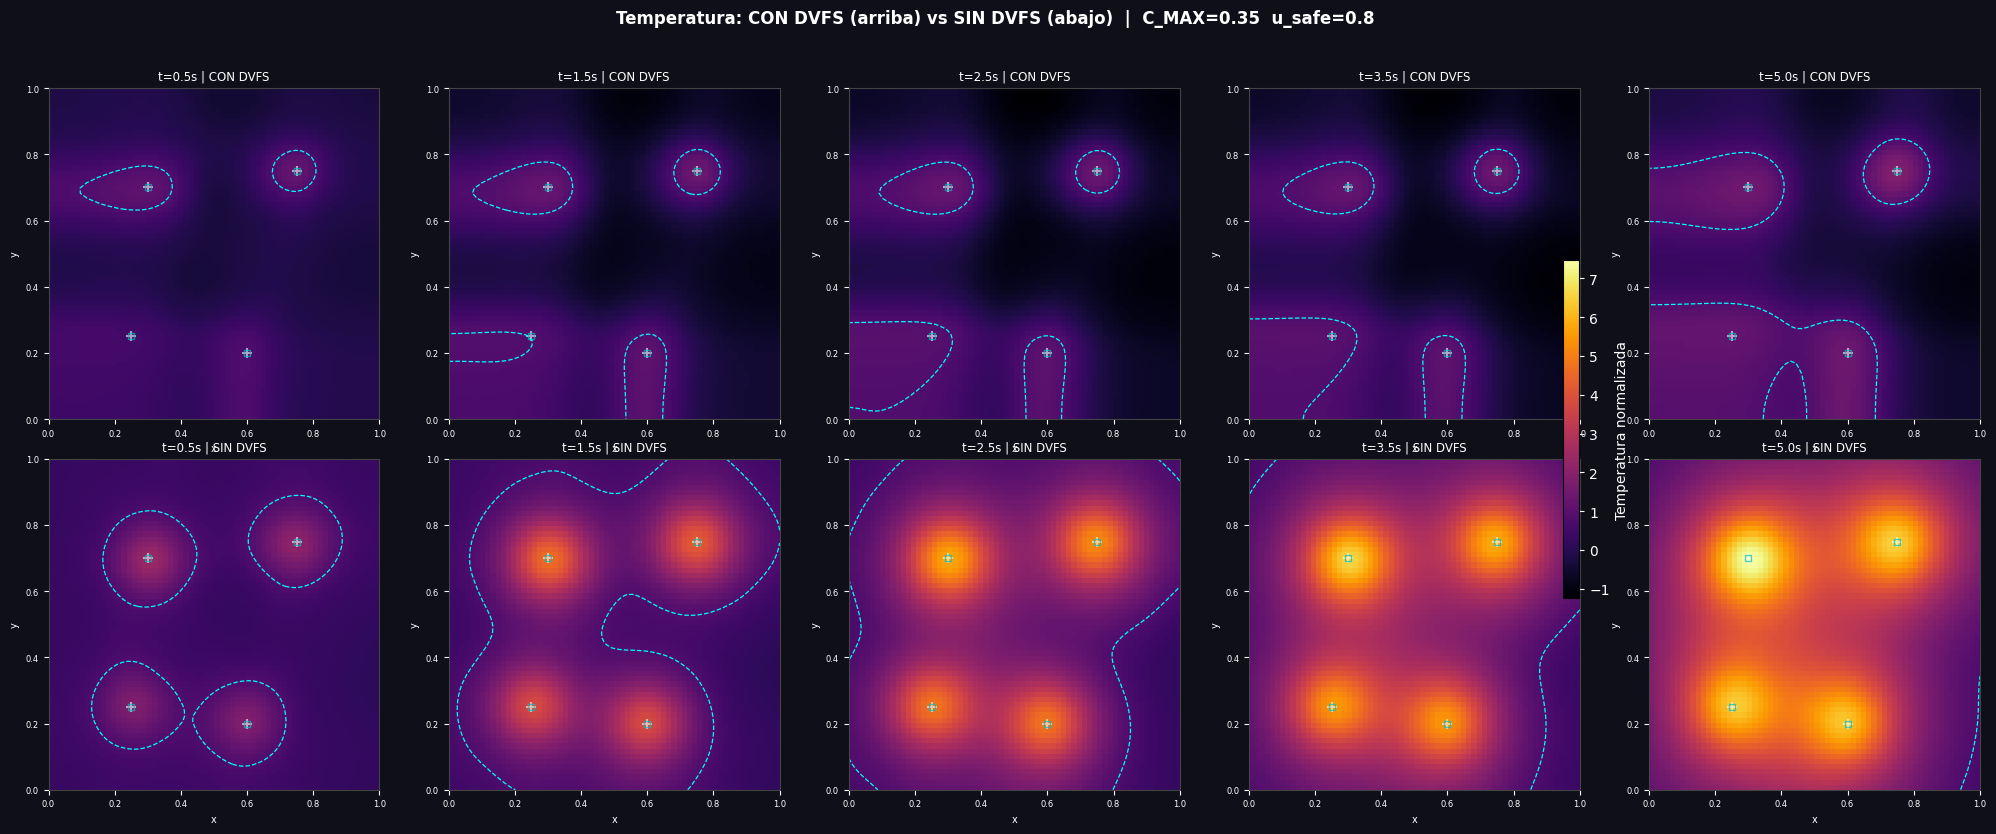

Resultado fisicamente realista:
  SIN DVFS: hotspots crecen y persisten
  CON DVFS: hotspots reducidos maximo 35%, NO eliminados
  La diferencia de temperatura es parcial, no total


In [78]:
t_snaps = [0.5, 1.5, 2.5, 3.5, T_FINAL]
all_u = ([eval_temperature(tv, True)  for tv in t_snaps] +
         [eval_temperature(tv, False) for tv in t_snaps])
vmin_s = min(f.min() for f in all_u)
vmax_s = max(f.max() for f in all_u)
xs_v = np.linspace(0,1,N_VIS); ys_v = np.linspace(0,1,N_VIS)

fig, axes = plt.subplots(2, len(t_snaps), figsize=(20, 8))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle(f"Temperatura: CON DVFS (arriba) vs SIN DVFS (abajo)  |  C_MAX={C_MAX}  u_safe={u_safe}",
             color='white', fontsize=12, fontweight='bold', y=1.02)

for col, tv in enumerate(t_snaps):
    u_c  = eval_temperature(tv, True)
    u_nc = eval_temperature(tv, False)
    for row, (U, lbl) in enumerate([(u_c,"CON DVFS"),(u_nc,"SIN DVFS")]):
        ax = axes[row, col]
        ax.set_facecolor('#0f0f1a')
        im = ax.imshow(U.T, origin='lower', extent=[0,1,0,1],
                       vmin=vmin_s, vmax=vmax_s, cmap='inferno', aspect='equal')
        ax.set_title(f"t={tv:.1f}s | {lbl}", color='white', fontsize=8.5)
        ax.set_xlabel("x", color='white', fontsize=7)
        ax.set_ylabel("y", color='white', fontsize=7)
        ax.tick_params(colors='white', labelsize=6)
        for sp in ax.spines.values(): sp.set_edgecolor('#444')
        for cx,cy in HEAT_CENTERS:
            ax.plot(cx,cy,'w+',markersize=7,markeredgewidth=1.5,alpha=0.6)
        for ax_,ay_ in ACTUATOR_CENTERS:
            ax.plot(ax_,ay_,'cs',markersize=5,markerfacecolor='none',
                    markeredgewidth=1,alpha=0.7)
        try:
            ax.contour(xs_v,ys_v,U.T,levels=[u_safe],
                       colors='cyan',linewidths=0.9,linestyles='--')
        except: pass

cb = plt.colorbar(im, ax=axes, label='Temperatura normalizada', shrink=0.55, pad=0.02)
cb.set_label('Temperatura normalizada', color='white')
cb.ax.yaxis.set_tick_params(color='white')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')
plt.tight_layout()
plt.savefig("snapshot_comparison_v3.png", dpi=130, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Resultado fisicamente realista:")
print(f"  SIN DVFS: hotspots crecen y persisten")
print(f"  CON DVFS: hotspots reducidos maximo {C_MAX*100:.0f}%, NO eliminados")
print("  La diferencia de temperatura es parcial, no total")


## 10. Visualizacion del control DVFS: gate, campo y actuadores

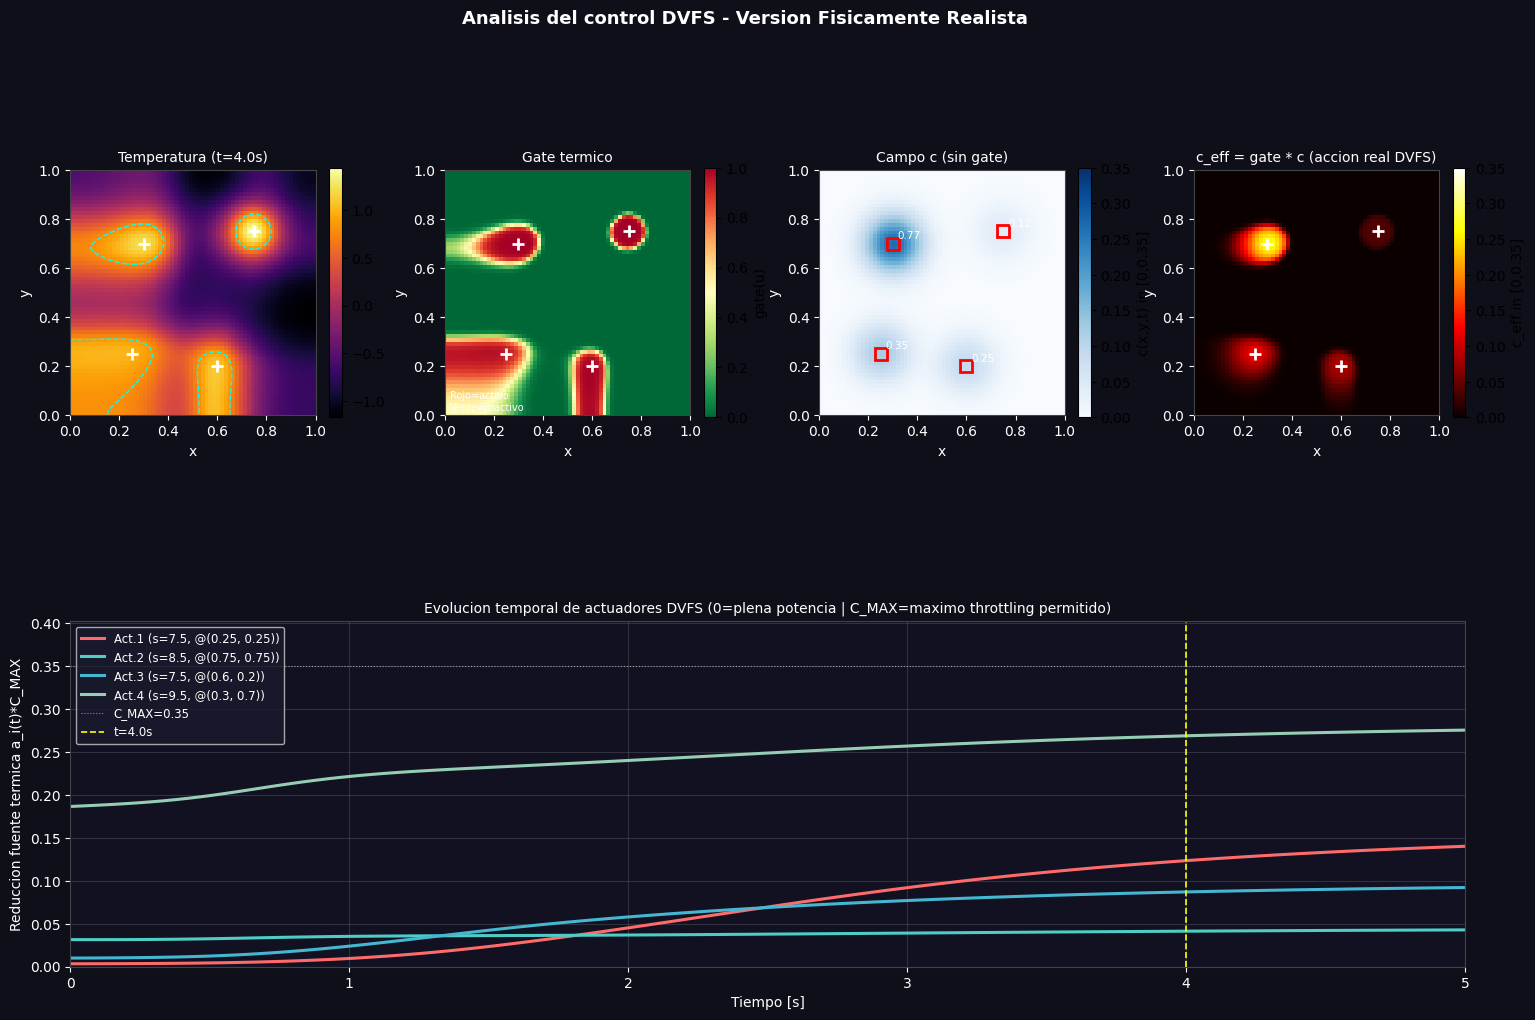

Intensidades a_i*C_MAX en t=4.0s:
  Act.1: 0.1235 (35.3% del max)  [#######             ]
  Act.2: 0.0414 (11.8% del max)  [##                  ]
  Act.3: 0.0871 (24.9% del max)  [####                ]
  Act.4: 0.2688 (76.8% del max)  [###############     ]


In [79]:
t_show = 4.0

c_eff_vis, c_vis, gate_vis, a_vals = eval_control_field(t_show)
u_ctrl_vis = eval_temperature(t_show, True)
t_ser, a_ser = eval_actuator_timeseries(n_t=120)

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor('#0f0f1a')
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.38)

def dark_ax(ax):
    ax.set_facecolor('#0f0f1a'); ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_edgecolor('#444')

# Temperatura
ax = fig.add_subplot(gs[0,0]); dark_ax(ax)
im = ax.imshow(u_ctrl_vis.T, origin='lower', extent=[0,1,0,1],
               cmap='inferno', aspect='equal')
plt.colorbar(im, ax=ax, label='u', fraction=0.046)
ax.set_title(f"Temperatura (t={t_show}s)", color='white', fontsize=10)
ax.set_xlabel("x",color='white'); ax.set_ylabel("y",color='white')
try: ax.contour(np.linspace(0,1,N_VIS),np.linspace(0,1,N_VIS),u_ctrl_vis.T,
                levels=[u_safe],colors='cyan',linewidths=1.0,linestyles='--')
except: pass
for cx,cy in HEAT_CENTERS: ax.plot(cx,cy,'w+',markersize=9,markeredgewidth=2)

# Gate
ax = fig.add_subplot(gs[0,1]); dark_ax(ax)
im = ax.imshow(gate_vis.T, origin='lower', extent=[0,1,0,1],
               cmap='RdYlGn_r', aspect='equal', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='gate(u)', fraction=0.046)
ax.set_title("Gate termico", color='white', fontsize=10)
ax.set_xlabel("x",color='white'); ax.set_ylabel("y",color='white')
ax.text(0.02,0.02,'Rojo=activo\nVerde=inactivo',color='white',fontsize=7,transform=ax.transAxes)
for cx,cy in HEAT_CENTERS: ax.plot(cx,cy,'w+',markersize=9,markeredgewidth=2)

# Campo c
ax = fig.add_subplot(gs[0,2]); dark_ax(ax)
im = ax.imshow(c_vis.T, origin='lower', extent=[0,1,0,1],
               cmap='Blues', aspect='equal', vmin=0, vmax=C_MAX)
plt.colorbar(im, ax=ax, label=f'c(x,y,t) in [0,{C_MAX}]', fraction=0.046)
ax.set_title("Campo c (sin gate)", color='white', fontsize=10)
ax.set_xlabel("x",color='white'); ax.set_ylabel("y",color='white')
for i,(ax_,ay_) in enumerate(ACTUATOR_CENTERS):
    ax.plot(ax_,ay_,'rs',markersize=9,markerfacecolor='none',markeredgewidth=2)
    ax.text(ax_+0.02,ay_+0.02,f'{a_vals[i]:.2f}',color='white',fontsize=7.5)

# c_eff = gate * c
ax = fig.add_subplot(gs[0,3]); dark_ax(ax)
im = ax.imshow(c_eff_vis.T, origin='lower', extent=[0,1,0,1],
               cmap='hot', aspect='equal', vmin=0, vmax=C_MAX)
plt.colorbar(im, ax=ax, label=f'c_eff in [0,{C_MAX}]', fraction=0.046)
ax.set_title("c_eff = gate * c (accion real DVFS)", color='white', fontsize=10)
ax.set_xlabel("x",color='white'); ax.set_ylabel("y",color='white')
for cx,cy in HEAT_CENTERS: ax.plot(cx,cy,'w+',markersize=9,markeredgewidth=2)

# Series temporales
ax = fig.add_subplot(gs[1,:]); ax.set_facecolor('#111122')
for sp in ax.spines.values(): sp.set_edgecolor('#444')
cols_act=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4']
for i in range(N_ACTUATORS):
    ax.plot(t_ser, a_ser[:,i]*C_MAX, color=cols_act[i%4], lw=2.2,
            label=f'Act.{i+1} (s={HEAT_STRENGTHS[i]}, @{ACTUATOR_CENTERS[i]})')
ax.axhline(C_MAX, color='white', ls=':', lw=0.8, alpha=0.5, label=f'C_MAX={C_MAX}')
ax.axvline(t_show, color='yellow', ls='--', lw=1.2, label=f't={t_show}s')
ax.set_xlabel("Tiempo [s]", color='white', fontsize=10)
ax.set_ylabel("Reduccion fuente termica a_i(t)*C_MAX", color='white', fontsize=10)
ax.set_title("Evolucion temporal de actuadores DVFS (0=plena potencia | C_MAX=maximo throttling permitido)",color='white', fontsize=10)
ax.set_xlim(0,T_FINAL); ax.set_ylim(0, C_MAX*1.15)
ax.tick_params(colors='white')
ax.legend(fontsize=8.5,facecolor='#1a1a2e',labelcolor='white',framealpha=0.8)
ax.grid(True, alpha=0.2)

fig.suptitle("Analisis del control DVFS - Version Fisicamente Realista",
             color='white', fontsize=13, fontweight='bold')
plt.savefig("dvfs_analysis_v3.png", dpi=130, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(f"Intensidades a_i*C_MAX en t={t_show}s:")
for i,av in enumerate(a_vals):
    eff=av*C_MAX; bar='#'*int(eff/C_MAX*20)
    print(f"  Act.{i+1}: {eff:.4f} ({eff/C_MAX*100:.1f}% del max)  [{bar:<20}]")


## 11. Animacion comparativa

In [81]:
print("Pre-calculando campos...")

t_anim = np.linspace(0, T_FINAL, T_FRAMES)

fields_ctrl = [eval_temperature(tv, True)  for tv in t_anim]
fields_ref  = [eval_temperature(tv, False) for tv in t_anim]
fields_ceff = [eval_control_field(tv)[0]   for tv in t_anim]

vmin_a = min(
    min(f.min() for f in fields_ctrl),
    min(f.min() for f in fields_ref)
)

vmax_a = max(
    max(f.max() for f in fields_ctrl),
    max(f.max() for f in fields_ref)
)

xs_v = np.linspace(0, 1, N_VIS)
ys_v = np.linspace(0, 1, N_VIS)

# ============================================================================
# FIGURA
# ============================================================================

fig_a = plt.figure(figsize=(18, 5.8))
fig_a.patch.set_facecolor('#0f0f1a')

gs_a = gridspec.GridSpec(
    1, 3,
    figure=fig_a,
    wspace=0.35
)

ax1 = fig_a.add_subplot(gs_a[0])
ax2 = fig_a.add_subplot(gs_a[1])
ax3 = fig_a.add_subplot(gs_a[2])

for ax in [ax1, ax2, ax3]:

    ax.set_facecolor('#0f0f1a')
    ax.tick_params(colors='white')

    for sp in ax.spines.values():
        sp.set_edgecolor('#444')


# ============================================================================
# MAPAS DE CALOR
# ============================================================================

im1 = ax1.imshow(
    fields_ref[0].T,
    origin='lower',
    extent=[0,1,0,1],
    vmin=vmin_a,
    vmax=vmax_a,
    cmap='inferno',
    aspect='equal'
)

im2 = ax2.imshow(
    fields_ctrl[0].T,
    origin='lower',
    extent=[0,1,0,1],
    vmin=vmin_a,
    vmax=vmax_a,
    cmap='inferno',
    aspect='equal'
)

im3 = ax3.imshow(
    fields_ceff[0].T,
    origin='lower',
    extent=[0,1,0,1],
    vmin=0,
    vmax=C_MAX,
    cmap='hot',
    aspect='equal'
)

# ============================================================================
# TITULOS
# ============================================================================

ax1.set_title(
    "SIN DVFS (referencia)",
    color='white',
    fontsize=11,
    pad=6
)

ax2.set_title(
    f"CON DVFS (max {C_MAX*100:.0f}% throttling)",
    color='white',
    fontsize=11,
    pad=6
)

ax3.set_title(
    f"c_eff = gate*c  in [0,{C_MAX}]",
    color='white',
    fontsize=11,
    pad=6
)

# ============================================================================
# EJES + HOTSPOTS
# ============================================================================

for ax in [ax1, ax2, ax3]:

    ax.set_xlabel("x", color='white')
    ax.set_ylabel("y", color='white')

    for cx, cy in HEAT_CENTERS:
        ax.plot(
            cx,
            cy,
            'w+',
            markersize=8,
            markeredgewidth=1.8,
            alpha=0.6
        )

# ============================================================================
# COLORBARS
# ============================================================================

for cb_ax, im, lbl in [
    (ax1, im1, 'T norm.'),
    (ax2, im2, 'T norm.'),
    (ax3, im3, f'c_eff in [0,{C_MAX}]')
]:

    cb = plt.colorbar(
        im,
        ax=cb_ax,
        fraction=0.046,
        pad=0.04
    )

    cb.set_label(
        lbl,
        color='white',
        fontsize=8
    )

    cb.ax.yaxis.set_tick_params(color='white')

    plt.setp(
        cb.ax.yaxis.get_ticklabels(),
        color='white'
    )

# ============================================================================
# TEXTO SUPERIOR
# ============================================================================

time_txt = fig_a.text(
    0.5,
    0.97,
    '',
    ha='center',
    color='white',
    fontsize=12,
    fontweight='bold'
)

# ============================================================================
# CONTORNOS
# ============================================================================

cont1 = [None]
cont2 = [None]

def _upd(ax, data, cr):

    # borrar contour anterior
    if cr[0] is not None:
        try:
            cr[0].remove()
        except:
            pass

    # crear nuevo contour
    try:

        cr[0] = ax.contour(
            xs_v,
            ys_v,
            data,
            levels=[u_safe],
            colors='cyan',
            linewidths=1.0
        )

    except:
        cr[0] = None


# ============================================================================
# UPDATE ANIMACION
# ============================================================================

def update_anim(frame):

    im1.set_data(fields_ref[frame].T)
    im2.set_data(fields_ctrl[frame].T)
    im3.set_data(fields_ceff[frame].T)

    time_txt.set_text(
        f"t = {t_anim[frame]:.2f}s  |  PINN-DVFS v3 realista"
    )

    _upd(ax1, fields_ref[frame].T,  cont1)
    _upd(ax2, fields_ctrl[frame].T, cont2)

    return [im1, im2, im3, time_txt]

# ============================================================================
# FRAME INICIAL
# ============================================================================

_upd(ax1, fields_ref[0].T, cont1)
_upd(ax2, fields_ctrl[0].T, cont2)

# ============================================================================
# LAYOUT
# ============================================================================

fig_a.subplots_adjust(
    top=0.90,
    wspace=0.30
)

# ============================================================================
# ANIMACION
# ============================================================================

anim = animation.FuncAnimation(
    fig_a,
    update_anim,
    frames=T_FRAMES,
    interval=130,
    blit=False
)

gif_path = "chip_dvfs_v3.gif"

anim.save(
    gif_path,
    writer=animation.PillowWriter(fps=7),
    dpi=95
)

plt.close(fig_a)

# ============================================================================
# INFO FINAL
# ============================================================================

print(f"GIF guardado: {gif_path}")
print(f"  Panel izq: SIN DVFS")
print(f"  Panel med: CON DVFS (reduccion max {C_MAX*100:.0f}%)")
print(f"  Panel der: c_eff - donde y cuanto actua el DVFS")
print(f"  Contorno cian = isoterma u_safe")

Pre-calculando campos...
GIF guardado: chip_dvfs_v3.gif
  Panel izq: SIN DVFS
  Panel med: CON DVFS (reduccion max 35%)
  Panel der: c_eff - donde y cuanto actua el DVFS
  Contorno cian = isoterma u_safe


## 12. Metricas cuantitativas

/var/folders/7_/jx69qx9x14vcjds7rh_4np4w0000gn/T/ipykernel_53501/832385573.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_ctrl=np.trapz(M_d["ceff_mean"], t_m)


METRICAS - PINN-DVFS v3 (Fisicamente Realista)
  T_max(t=T_FINAL): SIN=7.4837  CON=1.8602  Reduccion=75.1%
  Esperado: reduccion <= 35% (=C_MAX)
  Fraccion hotspot: SIN=72.71%  CON=12.88%  Red=82.3%
  Energia de control acumulada: 0.03852
  c_eff max observado: 0.2754  (debe <= C_MAX=0.35)
ADVERTENCIA: reduccion mayor que C_MAX*100% - revisar implementacion


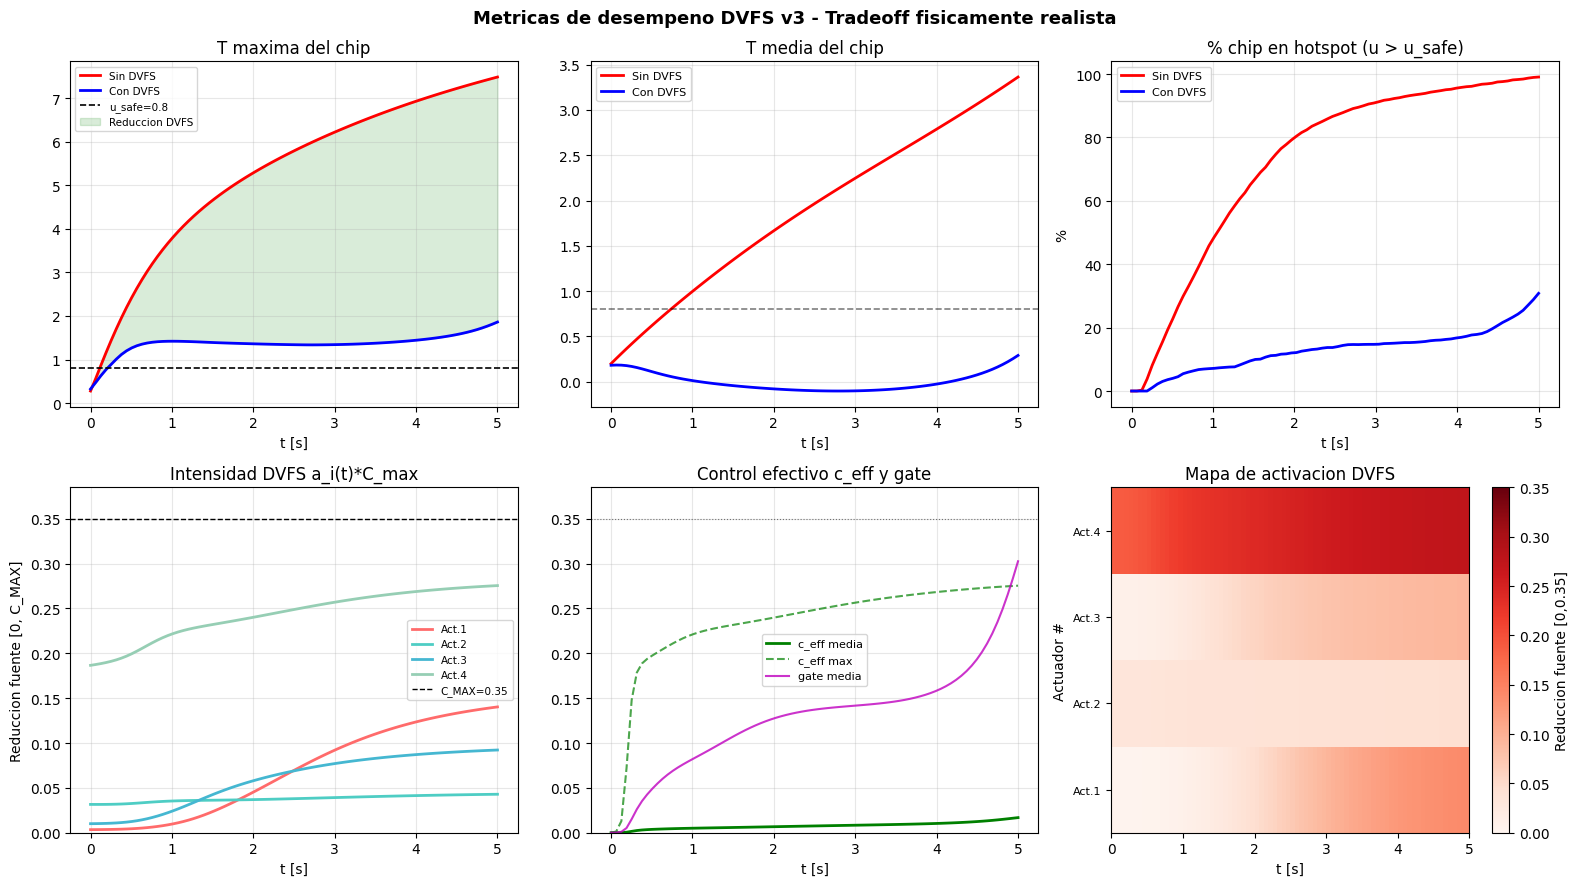

Metricas guardadas


In [82]:
t_m = np.linspace(0, T_FINAL, 80)
M_d = dict(t=t_m,
           u_max_ctrl=np.zeros(80), u_max_ref=np.zeros(80),
           u_mean_ctrl=np.zeros(80), u_mean_ref=np.zeros(80),
           hot_ctrl=np.zeros(80), hot_ref=np.zeros(80),
           ceff_mean=np.zeros(80), ceff_max=np.zeros(80), gate_mean=np.zeros(80))

for i,tv in enumerate(t_m):
    uc  = eval_temperature(tv, True)
    unc = eval_temperature(tv, False)
    ce_f,c_f,g_f,av = eval_control_field(tv)
    M_d["u_max_ctrl"][i]  = uc.max(); M_d["u_max_ref"][i]   = unc.max()
    M_d["u_mean_ctrl"][i] = uc.mean(); M_d["u_mean_ref"][i] = unc.mean()
    M_d["hot_ctrl"][i]    = np.mean(uc>u_safe); M_d["hot_ref"][i] = np.mean(unc>u_safe)
    M_d["ceff_mean"][i]   = ce_f.mean(); M_d["ceff_max"][i] = ce_f.max()
    M_d["gate_mean"][i]   = g_f.mean()

dU=(M_d["u_max_ref"][-1]-M_d["u_max_ctrl"][-1])
pU=dU/max(M_d["u_max_ref"][-1],1e-9)*100
dH=M_d["hot_ref"].mean()-M_d["hot_ctrl"].mean()
pH=dH/max(M_d["hot_ref"].mean(),1e-9)*100
E_ctrl=np.trapz(M_d["ceff_mean"], t_m)

print("=" * 60)
print("METRICAS - PINN-DVFS v3 (Fisicamente Realista)")
print("=" * 60)
print(f"  T_max(t=T_FINAL): SIN={M_d['u_max_ref'][-1]:.4f}  CON={M_d['u_max_ctrl'][-1]:.4f}  Reduccion={pU:.1f}%")
print(f"  Esperado: reduccion <= {C_MAX*100:.0f}% (=C_MAX)")
print(f"  Fraccion hotspot: SIN={M_d['hot_ref'].mean()*100:.2f}%  CON={M_d['hot_ctrl'].mean()*100:.2f}%  Red={pH:.1f}%")
print(f"  Energia de control acumulada: {E_ctrl:.5f}")
print(f"  c_eff max observado: {M_d['ceff_max'].max():.4f}  (debe <= C_MAX={C_MAX})")
print("=" * 60)
if pU > C_MAX*100*1.5:
    print("ADVERTENCIA: reduccion mayor que C_MAX*100% - revisar implementacion")
elif pU > 3:
    print("OK: control efectivo y fisicamente plausible")
else:
    print("INFO: control debil - puede necesitar mas epocas")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Metricas de desempeno DVFS v3 - Tradeoff fisicamente realista",
             fontsize=13, fontweight='bold')

ax=axes[0,0]
ax.plot(t_m,M_d["u_max_ref"],'r-',lw=2,label="Sin DVFS")
ax.plot(t_m,M_d["u_max_ctrl"],'b-',lw=2,label="Con DVFS")
ax.axhline(u_safe,color='k',ls='--',lw=1.2,label=f"u_safe={u_safe}")
ax.fill_between(t_m,M_d["u_max_ctrl"],M_d["u_max_ref"],alpha=0.15,color='green',label='Reduccion DVFS')
ax.set_title("T maxima del chip"); ax.set_xlabel("t [s]")
ax.legend(fontsize=7.5); ax.grid(alpha=.3)

ax=axes[0,1]
ax.plot(t_m,M_d["u_mean_ref"],'r-',lw=2,label="Sin DVFS")
ax.plot(t_m,M_d["u_mean_ctrl"],'b-',lw=2,label="Con DVFS")
ax.axhline(u_safe,color='k',ls='--',lw=1.2,alpha=0.5)
ax.set_title("T media del chip"); ax.set_xlabel("t [s]")
ax.legend(fontsize=8); ax.grid(alpha=.3)

ax=axes[0,2]
ax.plot(t_m,M_d["hot_ref"]*100,'r-',lw=2,label="Sin DVFS")
ax.plot(t_m,M_d["hot_ctrl"]*100,'b-',lw=2,label="Con DVFS")
ax.set_title("% chip en hotspot (u > u_safe)")
ax.set_xlabel("t [s]"); ax.set_ylabel("%")
ax.legend(fontsize=8); ax.grid(alpha=.3)

ax=axes[1,0]
t_s,a_s=eval_actuator_timeseries(n_t=80)
cols_act=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4']
for i in range(N_ACTUATORS):
    ax.plot(t_s,a_s[:,i]*C_MAX,color=cols_act[i%4],lw=2,label=f'Act.{i+1}')
ax.axhline(C_MAX,color='k',ls='--',lw=1,label=f'C_MAX={C_MAX}')
ax.set_title(f"Intensidad DVFS a_i(t)*C_max"); ax.set_xlabel("t [s]")
ax.set_ylabel("Reduccion fuente [0, C_MAX]")
ax.legend(fontsize=7.5); ax.grid(alpha=.3); ax.set_ylim(0,C_MAX*1.1)

ax=axes[1,1]
ax.plot(t_m,M_d["ceff_mean"],'g-',lw=2,label='c_eff media')
ax.plot(t_m,M_d["ceff_max"],'g--',lw=1.5,alpha=0.7,label='c_eff max')
ax.plot(t_m,M_d["gate_mean"],'m-',lw=1.5,alpha=0.8,label='gate media')
ax.axhline(C_MAX,color='k',ls=':',lw=0.8,alpha=0.5)
ax.set_title("Control efectivo c_eff y gate")
ax.set_xlabel("t [s]"); ax.legend(fontsize=8); ax.grid(alpha=.3); ax.set_ylim(0,C_MAX*1.1)

ax=axes[1,2]
im_h=ax.imshow(a_s.T*C_MAX, aspect='auto', origin='lower',
               extent=[0,T_FINAL,0,N_ACTUATORS], cmap='Reds', vmin=0, vmax=C_MAX)
plt.colorbar(im_h,ax=ax,label=f'Reduccion fuente [0,{C_MAX}]')
ax.set_title("Mapa de activacion DVFS")
ax.set_xlabel("t [s]"); ax.set_ylabel("Actuador #")
ax.set_yticks(np.arange(N_ACTUATORS)+0.5)
ax.set_yticklabels([f'Act.{i+1}' for i in range(N_ACTUATORS)],fontsize=8)

plt.tight_layout()
plt.savefig("dvfs_metrics_v3.png", dpi=120, bbox_inches='tight')
plt.show()
print("Metricas guardadas")


## 13. Diagnostico de realismo fisico

Checklist para verificar que el sistema DVFS se comporta correctamente.

| Condicion | Que verificar | Como corregir si falla |
|---|---|---|
| Hotspots sin control | u_max_ref > u_safe para t > 1 | Subir HEAT_STRENGTHS o bajar alpha |
| Control parcial | u_max_ctrl < u_max_ref pero > u_init | Si cero: subir lambda_hotspot. Si total: bajar C_MAX |
| Reduccion <= C_MAX | Porcentaje de reduccion <= C_MAX*100 | Revisar clamp en control_field |
| DVFS reactivo | a_i(t) crece con el tiempo | Revisar warm-up y gate |
| Sin throttling preventivo | c_eff ~ 0 para t pequeno | Subir BETA_GATE o lambda_usage |
| Suavidad temporal | a_i(t) sin oscilaciones bruscas | Subir lambda_smooth |


## 14. Evolucion del modelo: v1 -> v2 -> v3

| Aspecto | v1 (gate distribuido) | v2 (DVFS agresivo) | v3 (DVFS realista) |
|---|---|---|---|
| Mecanismo | Extraccion activa c<0 | Reduccion fuente c in [0,1] | Reduccion limitada c in [0,C_MAX] |
| Activacion | Gate sigmoidal | Sin gate (siempre activo) | Gate termico + C_MAX |
| Throttling max | Ilimitado | 100% (elimina fuente) | 35% (fuga irreducible) |
| Ratio hot/energy | 16 | 16 | 1.7 (equilibrado) |
| Penalizacion uso | No | No | lambda_usage*E[c] (lineal) |
| Suavidad temporal | No | No | lambda_smooth*||da/dt||^2 |
| Normalizacion t | t in [0,1] | t in [0,T_FINAL] | t/T_FINAL in [0,1] corregido |
| Penalizacion hotspot | softplus^2 | ReLU^2 | ReLU^2 |
| Resultado | Control muerto c~0 | Chip apagado termicamente | Throttling parcial y reactivo |
| Realismo fisico | Bajo | Muy bajo | Moderado-alto |

## Extensiones futuras

1. Feedback de temperatura: ControlNet recibe estadisticas de temperatura
   como input (no solo t), modelando sensores on-chip reales.

2. P-states discretos: throttling en pasos discretos via Gumbel-softmax.

3. Chips heterogeneos: distintos alpha(x,y), distintos u_safe por zona.

4. Validacion con FEM: comparar PINN con solver clasico (FEniCS, COMSOL).

5. DVFS predictivo con MPC: usar la PINN como modelo de prediccion
   para anticiparse a hotspots antes de que ocurran.
